In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU(True),
            nn.Flatten(),
            nn.Linear(64*7*7, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64*7*7),
            nn.ReLU(True),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # 7x7 -> 14x14
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Sigmoid()  # Output pixel values between 0 and 1
        )

    def forward(self, x):
        latent = self.encoder(x)
        out = self.decoder(latent)
        return out, latent

latent_dim = 64
model = DenoisingAutoencoder(latent_dim).to(device)
print(f"Latent dimension: {latent_dim}")


Latent dimension: 64


In [28]:
class AddNoise(object):
    def __init__(self, noise_factor=0.3):
        self.noise_factor = noise_factor

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.noise_factor
        noisy_tensor = tensor + noise
        noisy_tensor = torch.clamp(noisy_tensor, 0., 1.)
        return noisy_tensor

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='/content/drive/MyDrive/Model/data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='/content/drive/MyDrive/Model/data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [30]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10
noise_factor = 0.3

best_loss = float('inf')  # Initialize best loss with infinity

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        noisy_imgs = imgs + noise_factor * torch.randn_like(imgs)
        noisy_imgs = torch.clamp(noisy_imgs, 0., 1.)

        optimizer.zero_grad()
        outputs, _ = model(noisy_imgs)
        loss = criterion(outputs, imgs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

    # Save the best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), "/content/drive/MyDrive/Model/best_denoising_autoencoder.pth")
        print(f"Best model saved at epoch {epoch+1} with loss {best_loss:.4f}")


Epoch [1/10], Loss: 0.0091
Best model saved at epoch 1 with loss 0.0091
Epoch [2/10], Loss: 0.0072
Best model saved at epoch 2 with loss 0.0072
Epoch [3/10], Loss: 0.0065
Best model saved at epoch 3 with loss 0.0065
Epoch [4/10], Loss: 0.0061
Best model saved at epoch 4 with loss 0.0061
Epoch [5/10], Loss: 0.0059
Best model saved at epoch 5 with loss 0.0059
Epoch [6/10], Loss: 0.0057
Best model saved at epoch 6 with loss 0.0057
Epoch [7/10], Loss: 0.0056
Best model saved at epoch 7 with loss 0.0056
Epoch [8/10], Loss: 0.0055
Best model saved at epoch 8 with loss 0.0055
Epoch [9/10], Loss: 0.0054
Best model saved at epoch 9 with loss 0.0054
Epoch [10/10], Loss: 0.0053
Best model saved at epoch 10 with loss 0.0053


In [31]:
model = DenoisingAutoencoder(latent_dim).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Model/best_denoising_autoencoder.pth"))
model.eval()


DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=3136, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=3136, bias=True)
    (1): ReLU(inplace=True)
    (2): Unflatten(dim=1, unflattened_size=(64, 7, 7))
    (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (6): Sigmoid()
  )
)

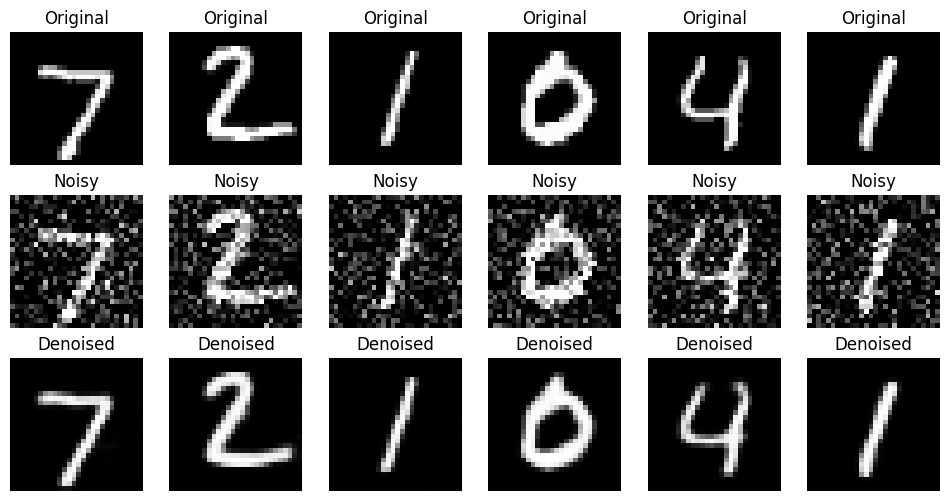

In [32]:
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        noisy_imgs = imgs + noise_factor * torch.randn_like(imgs)
        noisy_imgs = torch.clamp(noisy_imgs, 0., 1.)

        outputs, latent = model(noisy_imgs)

        # Show first 6 images: original, noisy, and denoised
        fig, axes = plt.subplots(3, 6, figsize=(12, 6))
        for i in range(6):
            axes[0, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
            axes[0, i].set_title("Original")
            axes[0, i].axis('off')

            axes[1, i].imshow(noisy_imgs[i].cpu().squeeze(), cmap='gray')
            axes[1, i].set_title("Noisy")
            axes[1, i].axis('off')

            axes[2, i].imshow(outputs[i].cpu().squeeze(), cmap='gray')
            axes[2, i].set_title("Denoised")
            axes[2, i].axis('off')
        plt.show()
        break


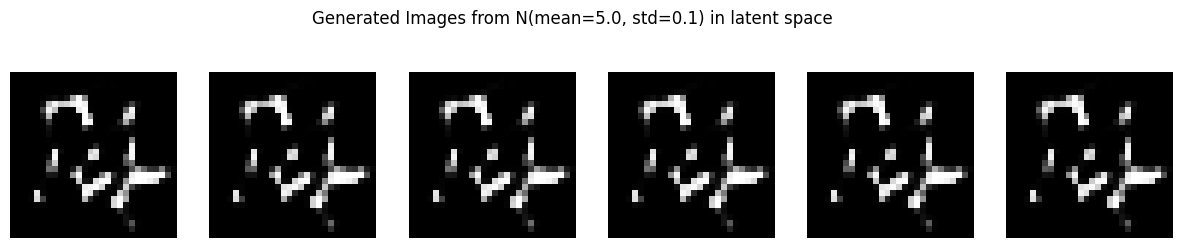

In [34]:
import torch
import matplotlib.pyplot as plt

latent_dim = 64
num_samples = 6
mean = 5.0
std_dev = 0.1
with torch.no_grad():
    sampled_latents = torch.randn(num_samples, latent_dim).to(device) * std_dev + mean

    generated_imgs = model.decoder(sampled_latents)

    generated_imgs = generated_imgs.cpu()

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
for i in range(num_samples):
    axes[i].imshow(generated_imgs[i].squeeze(), cmap='gray')
    axes[i].axis('off')
plt.suptitle(f"Generated Images from N(mean={mean}, std={std_dev}) in latent space")
plt.show()


In [35]:
model.eval()
latents_list = []

with torch.no_grad():
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        noisy_imgs = imgs + noise_factor * torch.randn_like(imgs)
        noisy_imgs = torch.clamp(noisy_imgs, 0., 1.)

        _, latent = model(noisy_imgs)  # Get latent vectors
        latents_list.append(latent.cpu())

# Concatenate all latent vectors: shape [num_samples, latent_dim]
all_latents = torch.cat(latents_list, dim=0)

# Calculate mean and variance across the dataset for each latent dimension
latent_mean = torch.mean(all_latents, dim=0)  # Shape: [latent_dim]
latent_var = torch.var(all_latents, dim=0)    # Shape: [latent_dim]

print("Learned latent mean:", latent_mean)
print("Learned latent variance:", latent_var)


Learned latent mean: tensor([-1.3622,  0.0955, -0.7470,  0.2752,  0.0737, -0.7575,  0.8172,  0.2121,
         1.5654,  1.4974,  1.0304,  1.8623, -0.1934, -0.1660,  0.6469,  0.6730,
        -2.1980,  0.5900,  0.1904, -0.3035, -0.9465,  0.0705, -0.7015,  0.7149,
         1.8085, -0.2480, -0.0897,  0.1296, -0.7996,  0.3697,  2.0574, -0.8940,
         0.1658,  0.8601, -0.2307, -1.8866,  0.2405, -0.6728, -0.4261, -0.8094,
        -0.5856,  0.8435,  0.2361,  0.6758,  1.0388, -1.7311, -1.6138,  0.4550,
        -0.4554, -0.0971,  1.0922, -0.3215,  0.4102, -1.7080,  0.8004,  1.6153,
        -0.3380, -0.5538,  0.8105,  1.4797,  1.2485, -0.1659,  0.1339,  1.0968])
Learned latent variance: tensor([2.7126, 2.5069, 2.2811, 2.3878, 3.2012, 4.1133, 2.3313, 3.0400, 3.2805,
        6.6049, 6.4355, 3.9054, 2.8258, 3.7345, 2.2761, 2.9578, 4.4352, 3.3208,
        2.5494, 5.0193, 3.2423, 2.1358, 2.0678, 3.4882, 4.9595, 2.8972, 5.4934,
        4.3498, 3.2933, 2.4666, 3.1035, 6.2599, 3.1654, 4.0824, 5.0564, 2

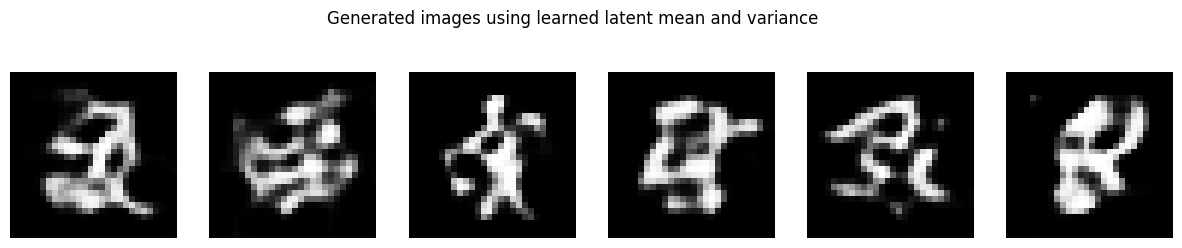

In [36]:
num_samples = 6

with torch.no_grad():
    # Sample noise ~ N(0,1)
    noise = torch.randn(num_samples, latent_dim)

    # Create samples by scaling noise with std and shifting by mean
    sampled_latents = noise * torch.sqrt(latent_var) + latent_mean  # shape: [num_samples, latent_dim]
    sampled_latents = sampled_latents.to(device)

    # Generate images from decoder
    generated_imgs = model.decoder(sampled_latents).cpu()

# Plot generated images
fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
for i in range(num_samples):
    axes[i].imshow(generated_imgs[i].squeeze(), cmap='gray')
    axes[i].axis('off')
plt.suptitle("Generated images using learned latent mean and variance")
plt.show()
